In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score


In [8]:
ev2 =  pd.read_csv('../../Datasets/evaluacion2.csv')
ev2.head(3)

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,No Badge,Sponsored,1,0,0,0.0,PC Components,Media,5.484755,0.000000,5.883322
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,No Badge,Sponsored,1,0,0,0.0,Storage & Memory Cards,Media,3.783962,0.000000,5.624018
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,Best Seller,Organic,0,1,0,0.0,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598


In [9]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(ev2)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,is_best_seller,7717,0,object,11
3,is_sponsored,7717,0,object,2
4,buy_box_availability,7717,0,int64,2
5,sustainability_tags,7717,0,int64,2
6,has_coupon,7717,0,int64,2
7,discount_percentage,7717,0,float64,72
8,product_category,7717,0,object,19
9,product_segment,7717,0,object,3


In [30]:
target = 'log_original_price'

In [ ]:
X = ev2.drop(columns=[target])
y = ev2[target]

In [33]:
# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to Pandas category
for col in cats:
   X[col] = X[col].astype('category')

In [36]:
X.dtypes

product_rating               float64
is_best_seller              category
is_sponsored                category
buy_box_availability           int64
sustainability_tags            int64
has_coupon                     int64
discount_percentage          float64
product_category            category
product_segment             category
log_purchased_last_month     float64
log_total_reviews            float64
dtype: object

In [37]:
X.shape, y.shape

((7717, 11), (7717,))

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

Dimensiones de X_train: (6173, 11)
Dimensiones de X_test:  (1544, 11)


C:\Users\USER\AppData\Local\Temp\ipykernel_3696\1541016602.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])


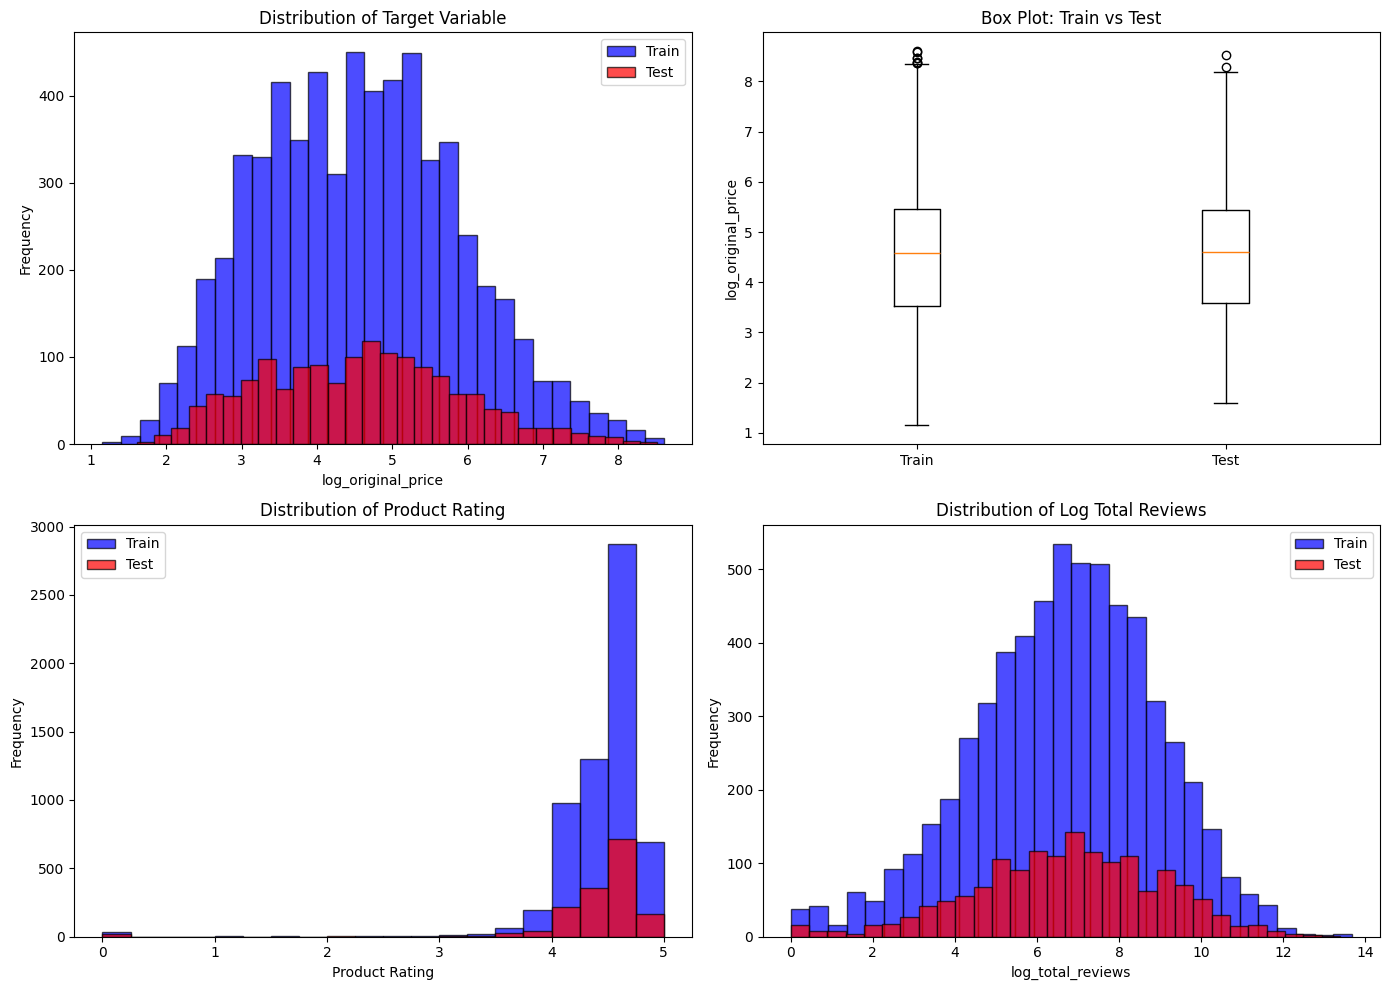

In [39]:
# Create visualizations for train and test data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of target variable
axes[0, 0].hist(y_train, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 0].hist(y_test, bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[0, 0].set_xlabel('log_original_price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Target Variable')
axes[0, 0].legend()

# 2. Box plot comparison
axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])
axes[0, 1].set_ylabel('log_original_price')
axes[0, 1].set_title('Box Plot: Train vs Test')

# 3. Product rating distribution
axes[1, 0].hist(X_train['product_rating'], bins=20, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 0].hist(X_test['product_rating'], bins=20, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Product Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Product Rating')
axes[1, 0].legend()

# 4. Log total reviews distribution
axes[1, 1].hist(X_train['log_total_reviews'], bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 1].hist(X_test['log_total_reviews'], bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 1].set_xlabel('log_total_reviews')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Log Total Reviews')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [40]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [43]:
# Define hyperparameters
params = {"objective": "reg:squarederror"}

In [44]:
n = 100
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

In [45]:
from sklearn.metrics import mean_squared_error

preds = model.predict(dtest_reg)

In [48]:
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(preds)
rmse = mean_squared_error(y_test_euro, y_pred_euro, squared=False)

print(f"RMSE of the base model: {rmse:.3f}")

RMSE of the base model: 234.544


c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


--- Métricas de Evaluación en Test Set ---
MSE:  55011.0828
RMSE: 234.5444
MAE:  97.4685
R²:   0.7042


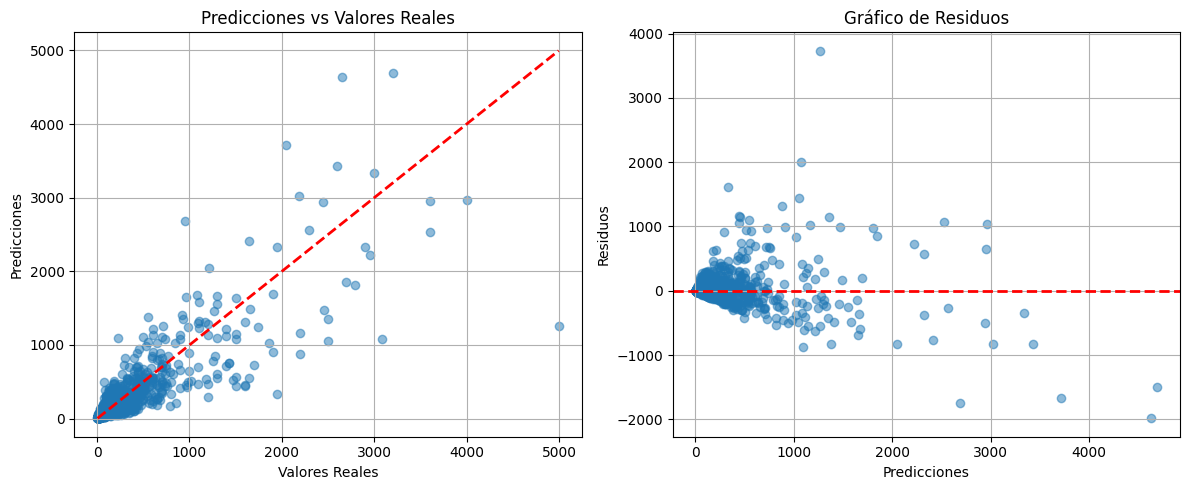

In [49]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_euro, y_pred_euro)
r2 = r2_score(y_test_euro, y_pred_euro)

print("--- Métricas de Evaluación en Test Set ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_euro, y_pred_euro, alpha=0.5)
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)

plt.subplot(1, 2, 2)
residuals = y_test_euro - y_pred_euro
plt.scatter(y_pred_euro, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True)

plt.tight_layout()
plt.show()

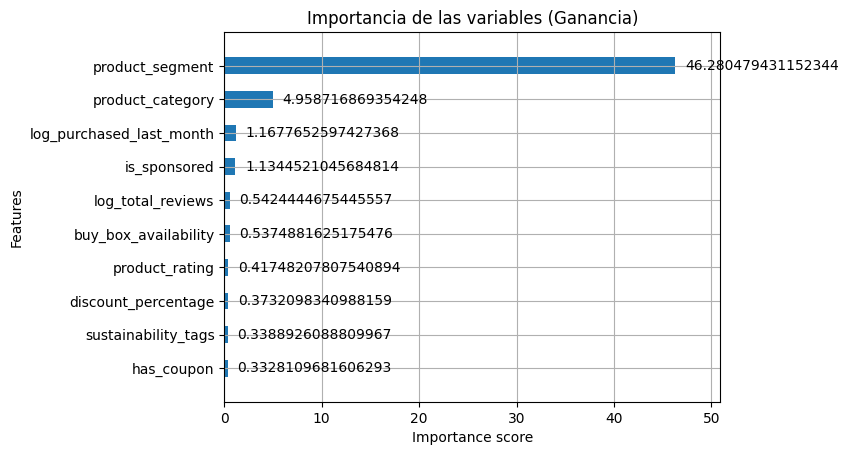

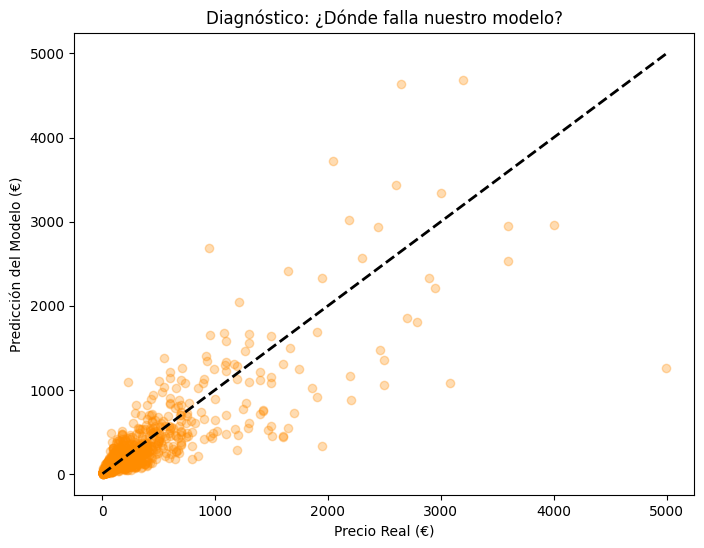

In [55]:
import xgboost as xgb
import matplotlib.pyplot as plt

# "weight" cuenta cuántas veces se usa la variable para dividir datos
# "gain" mide cuánto mejora la precisión del modelo cada vez que usa la variable (RECOMENDADO)
xgb.plot_importance(model, importance_type='gain', max_num_features=10, height=0.5)
plt.title("Importancia de las variables (Ganancia)")
plt.show()

# --- 4. GRÁFICO DE DIAGNÓSTICO: REAL VS PREDICHO ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_euro, y_pred_euro, alpha=0.3, color='darkorange')
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'k--', lw=2)
plt.xlabel("Precio Real (€)")
plt.ylabel("Predicción del Modelo (€)")
plt.title("Diagnóstico: ¿Dónde falla nuestro modelo?")
plt.show()

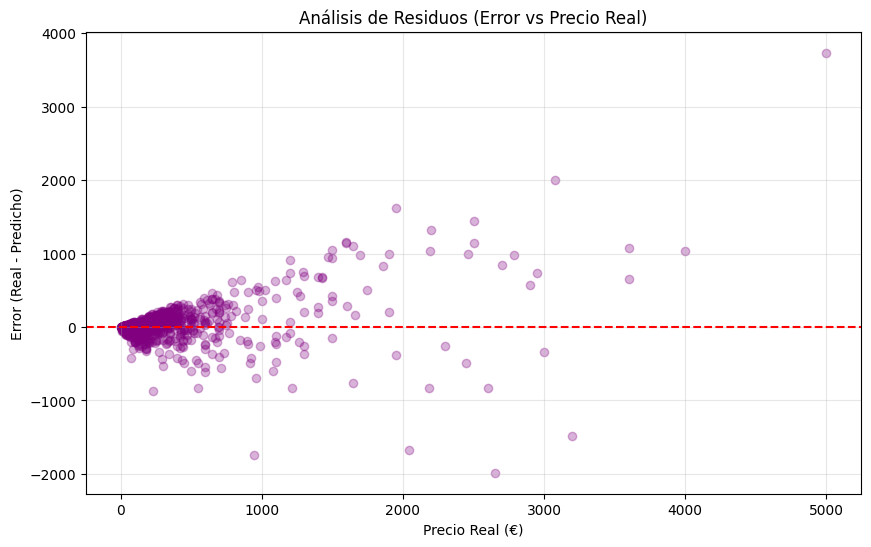

Error medio en productos de menos de 50€:
13.17 €

Error medio en productos de más de 500€:
479.85 €


In [51]:
import matplotlib.pyplot as plt

# Creamos una columna de error (Residuos)2
residuos = y_test_euro - y_pred_euro

plt.figure(figsize=(10, 6))
plt.scatter(y_test_euro, residuos, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Análisis de Residuos (Error vs Precio Real)")
plt.xlabel("Precio Real (€)")
plt.ylabel("Error (Real - Predicho)")
plt.grid(True, alpha=0.3)
plt.show()

# Veamos el error por tramos de precio
print("Error medio en productos de menos de 50€:")
mask = y_test_euro < 50
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

print("\nError medio en productos de más de 500€:")
mask = y_test_euro > 500
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

In [54]:
from sklearn.metrics import median_absolute_error

mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100


df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})


df_residuos['ErrorRelativo%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

for col in [c for c in X_test.columns if 'segment' in c]:
    mask = X_test[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'ErrorRelativo%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)


print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print(f"R2 Score (Calidad):      {r2_score(y_test_euro, y_pred_euro):.4f}")
# print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)


Segmento product_segment:
   - Error en Euros (MAE): nan €
   - Error en % (MAPE):    nan %
--------------------
📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      97.47 €
MedAE (Error Típico):   32.75 €
RMSE (Error Penalizado): 234.54 €
MAPE (Error Porcentual): 48.63 %
R2 Score (Calidad):      0.7042


# HASTA AQUÍ
ABAJO OTROS MODELOS DE XGBOOST

--- 

In [49]:
# --- PASO 2: Configuración del Modelo XGBoost ---
# Usamos parámetros sólidos para empezar. 
# 'n_estimators': número de árboles (iteraciones)
# 'max_depth': profundidad del árbol (controla la complejidad)
# 'learning_rate': velocidad de aprendizaje (menor es más preciso pero más lento)
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,     
    learning_rate=0.05,    
    max_depth=6,         
    subsample=0.8,        # Usa el 80% de los datos por árbol para evitar overfitting
    colsample_bytree=0.8, # Usa el 80% de las columnas por árbol
    random_state=42,
    n_jobs=-1       
)

In [44]:
# --- PASO 3: Entrenamiento con Early Stopping ---
print("Iniciando entrenamiento inteligente...")

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)], 
    verbose=False 
)

print(f"Mejor iteración: {xgb_model.best_iteration}")
print(f"Mejor score (RMSE): {xgb_model.best_score}")

Iniciando entrenamiento inteligente...
Mejor iteración: 149
Mejor score (RMSE): 0.8664917426649147


--- Métricas de Evaluación en Test Set ---
MSE:  119628.4748
RMSE: 345.8735
MAE:  141.8462
R²:   0.3568


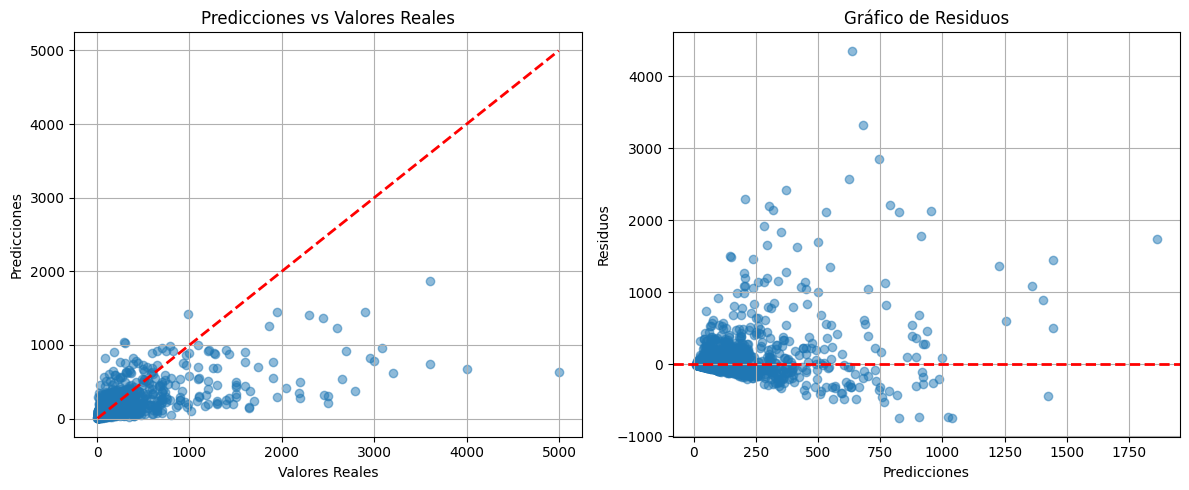

In [45]:
# 4 Evaluación
# Make predictions on test set
y_pred_log = xgb_model.predict(X_test)

# Invertimos el logaritmo para hablar en dinero (usando la fórmula de tu equipo)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred_log)

# Calculate evaluation metrics
mse = mean_squared_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_euro, y_pred_euro)
r2 = r2_score(y_test_euro, y_pred_euro)

print("--- Métricas de Evaluación en Test Set ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_euro, y_pred_euro, alpha=0.5)
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid(True)

plt.subplot(1, 2, 2)
residuals = y_test_euro - y_pred_euro
plt.scatter(y_pred_euro, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos')
plt.grid(True)

plt.tight_layout()
plt.show()

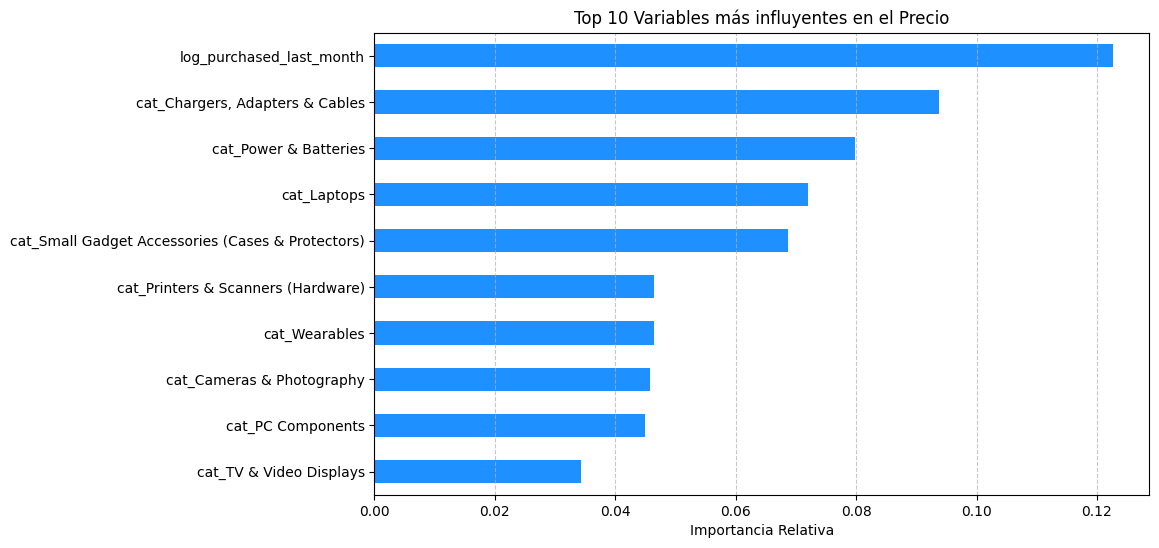

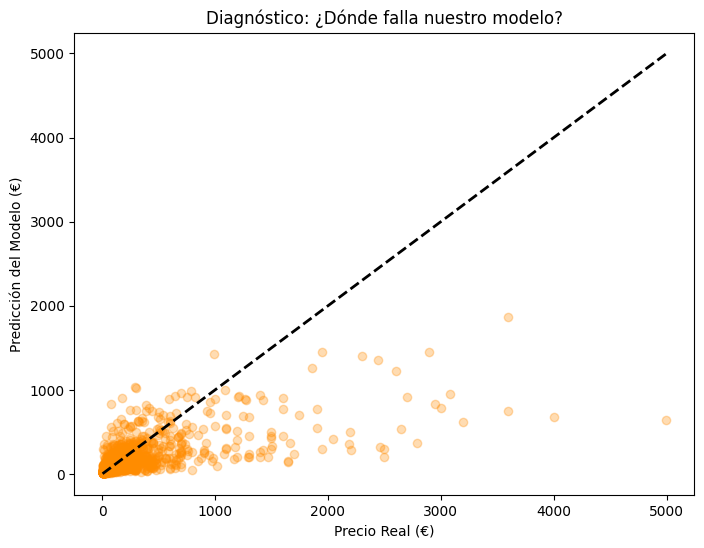

In [28]:
# --- 3. VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES ---
# Esto responde a: ¿Qué es lo que más hace subir el precio en Amazon?
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='dodgerblue')
plt.title("Top 10 Variables más influyentes en el Precio")
plt.xlabel("Importancia Relativa")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- 4. GRÁFICO DE DIAGNÓSTICO: REAL VS PREDICHO ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test_euro, y_pred_euro, alpha=0.3, color='darkorange')
plt.plot([y_test_euro.min(), y_test_euro.max()], [y_test_euro.min(), y_test_euro.max()], 'k--', lw=2)
plt.xlabel("Precio Real (€)")
plt.ylabel("Predicción del Modelo (€)")
plt.title("Diagnóstico: ¿Dónde falla nuestro modelo?")
plt.show()

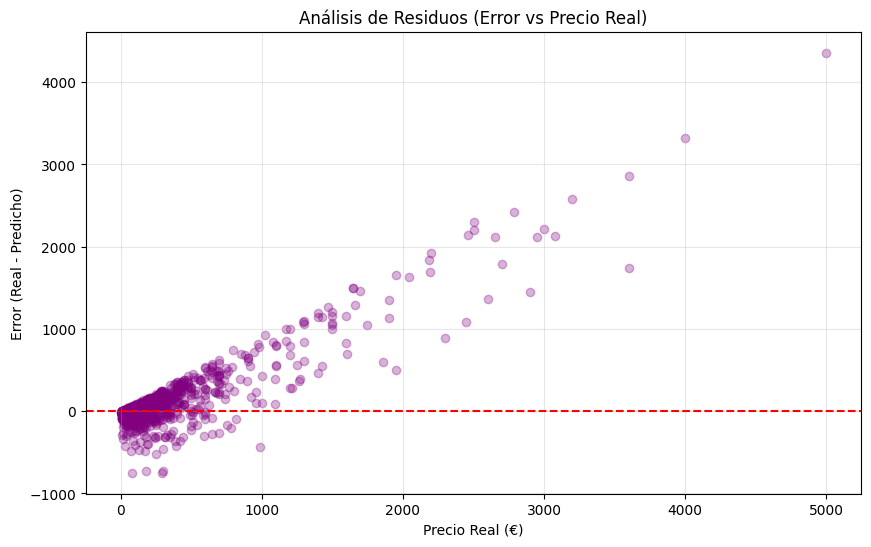

Error medio en productos de menos de 50€:
32.63 €

Error medio en productos de más de 500€:
744.13 €


In [ ]:
import matplotlib.pyplot as plt

# Creamos una columna de error (Residuos)2
residuos = y_test_euro - y_pred_euro

plt.figure(figsize=(10, 6))
plt.scatter(y_test_euro, residuos, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Análisis de Residuos (Error vs Precio Real)")
plt.xlabel("Precio Real (€)")
plt.ylabel("Error (Real - Predicho)")
plt.grid(True, alpha=0.3)
plt.show()

# Veamos el error por tramos de precio
print("Error medio en productos de menos de 50€:")
mask = y_test_euro < 50
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

print("\nError medio en productos de más de 500€:")
mask = y_test_euro > 500
if mask.any():
    print(f"{mean_absolute_error(y_test_euro[mask], y_pred_euro[mask]):.2f} €")

In [50]:
from sklearn.model_selection import GridSearchCV

# --- PASO 5: Ajuste de Hiperparámetros con GridSearchCV ---

# Definir la cuadrícula de parámetros a probar
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 700],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Crear GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar con GridSearchCV
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train, y_train)

# Resultados
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (CV): {-grid_search.best_score_:.4f}")

# Usar el mejor modelo
best_xgb_model = grid_search.best_estimator_
y_pred_best = best_xgb_model.predict(X_test)
y_pred_euro_best = np.expm1(y_pred_best)

# Evaluar el mejor modelo
mse_best = mean_squared_error(y_test_euro, y_pred_euro_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test_euro, y_pred_euro_best)
r2_best = r2_score(y_test_euro, y_pred_euro_best)

print("\n--- Métricas del Mejor Modelo ---")
print(f"RMSE: {rmse_best:.4f}")
print(f"MAE:  {mae_best:.4f}")
print(f"R²:   {r2_best:.4f}")

Iniciando búsqueda de hiperparámetros...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Mejores parámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
Mejor score (CV): 0.7757

--- Métricas del Mejor Modelo ---
RMSE: 342.3143
MAE:  140.7848
R²:   0.3700
